--- Проверка точности (N=128, n_min=2) ---
Разница (Naive vs Vinograd): 2.9139411421294264e-11
Разница (Naive vs Strassen): 3.479792681978919e-10
Результаты корректны!



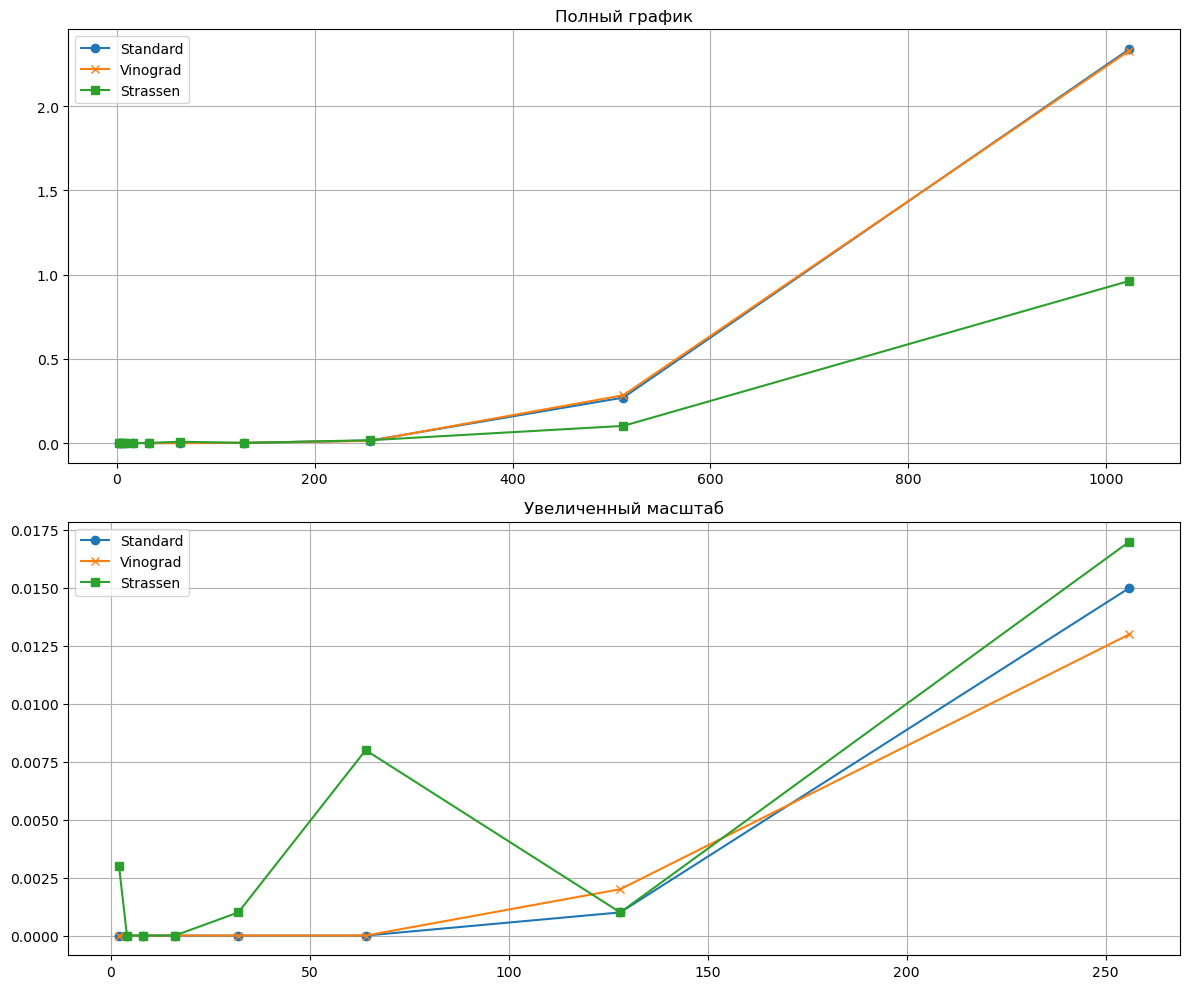

In [2]:
using Random
using LinearAlgebra
using PyPlot
using Statistics

function generate_matrix(l::Int, r::Int, n::Int)    
    return rand(n, n) .* (r - l) .+ l
end

function naive_matrix(A, B)
    n, m = size(A)
    m2, p = size(B)
    C = zeros(eltype(A), n, p)
    
    for i in 1:n
        for j in 1:p
            sum_val = zero(eltype(C))
            for k in 1:m
                sum_val += A[i, k] * B[k, j]
            end
            C[i, j] = sum_val
        end
    end
    return C
end

function vinograd(A, B)
    m, n = size(A)
    n2, p = size(B)    
    d = div(n, 2)
    
    C = zeros(Float64, m, p)
    RowFactor = zeros(Float64, m)
    ColFactor = zeros(Float64, p)
    
    for i in 1:m
        RowFactor[i] = sum(A[i, 2k-1] * A[i, 2k] for k in 1:d)
    end

    for j in 1:p
        ColFactor[j] = sum(B[2k-1, j] * B[2k, j] for k in 1:d)
    end

    for i in 1:m
        for j in 1:p
            s = -RowFactor[i] - ColFactor[j]
            C[i, j] = s + sum((A[i, 2k-1] + B[2k, j]) * (A[i, 2k] + B[2k-1, j]) for k in 1:d)
        end
    end
    
    if isodd(n)
        for i in 1:m
            for j in 1:p
                C[i, j] += A[i, n] * B[n, j]
            end
        end
    end

    return C
end

function strass_mat_mul(A, B, n_min)
    n = size(A, 1)
    effective_min = n > 64 ? 64 : n_min

    return strassen(A, B, effective_min)
end

function strassen(A, B, n_min)
    n = size(A, 1)

    if n <= n_min
        return naive_matrix(A, B)
    end    
    
    mid = div(n, 2)
    
    Auu = A[1:mid, 1:mid]      
    Auv = A[1:mid, mid+1:end]  
    Avu = A[mid+1:end, 1:mid]  
    Avv = A[mid+1:end, mid+1:end] 

    Buu = B[1:mid, 1:mid]      
    Buv = B[1:mid, mid+1:end]  
    Bvu = B[mid+1:end, 1:mid]  
    Bvv = B[mid+1:end, mid+1:end] 

    P1 = strassen(Auu + Avv, Buu + Bvv, n_min)
    P2 = strassen(Avu + Avv, Buu, n_min)
    P3 = strassen(Auu, Buv - Bvv, n_min)
    P4 = strassen(Avv, Bvu - Buu, n_min)
    P5 = strassen(Auu + Auv, Bvv, n_min)
    P6 = strassen(Avu - Auu, Buu + Buv, n_min)
    P7 = strassen(Auv - Avv, Bvu + Bvv, n_min)

    Cuu = P1 + P4 - P5 + P7
    Cuv = P3 + P5
    Cvu = P2 + P4
    Cvv = P1 - P2 + P3 + P6

    C = similar(A)
    C[1:mid, 1:mid] = Cuu
    C[1:mid, mid+1:end] = Cuv
    C[mid+1:end, 1:mid] = Cvu
    C[mid+1:end, mid+1:end] = Cvv

    return C
end

println("--- Проверка точности (N=128, n_min=2) ---")
N_test = 128
A_test = generate_matrix(-10, 10, N_test)
B_test = generate_matrix(-10, 10, N_test)

C_naive = naive_matrix(A_test, B_test)
C_vinograd = vinograd(A_test, B_test)
C_strassen = strassen(A_test, B_test, 2) 

diff_v = norm(C_naive - C_vinograd)
diff_s = norm(C_naive - C_strassen)

println("Разница (Naive vs Vinograd): $diff_v")
println("Разница (Naive vs Strassen): $diff_s")

if diff_v < 1e-9 && diff_s < 1e-9
    println("Результаты корректны!")
else
    println("Результаты некорректны")
end
println()

ns = [2^i for i in 1:10] 

time_naive = Float64[]
time_strassen = Float64[]
time_vinograd = Float64[]

n_min_strassen = 2

for dim in ns
    A = generate_matrix(-10, 10, dim)
    B = generate_matrix(-10, 10, dim)

    t = time()
    naive_matrix(A, B)
    push!(time_naive, time() - t)

    t = time()
    vinograd(A, B)
    push!(time_vinograd, time() - t)

    t = time()
    strass_mat_mul(A, B, n_min_strassen) 
    push!(time_strassen, time() - t)
end

PyPlot.figure(figsize=(12, 10))

PyPlot.subplot(2, 1, 1)
PyPlot.title("Полный график")
PyPlot.plot(ns, time_naive, label="Standard", marker="o")
PyPlot.plot(ns, time_vinograd, label="Vinograd", marker="x")
PyPlot.plot(ns, time_strassen, label="Strassen", marker="s")
PyPlot.grid(true)
PyPlot.legend()

PyPlot.subplot(2, 1, 2)
PyPlot.title("Увеличенный масштаб")
PyPlot.plot(ns[1:8], time_naive[1:8], label="Standard", marker="o")
PyPlot.plot(ns[1:8], time_vinograd[1:8], label="Vinograd", marker="x")
PyPlot.plot(ns[1:8], time_strassen[1:8], label="Strassen", marker="s")
PyPlot.grid(true)
PyPlot.legend()

PyPlot.tight_layout()
PyPlot.show()

sys:1: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown


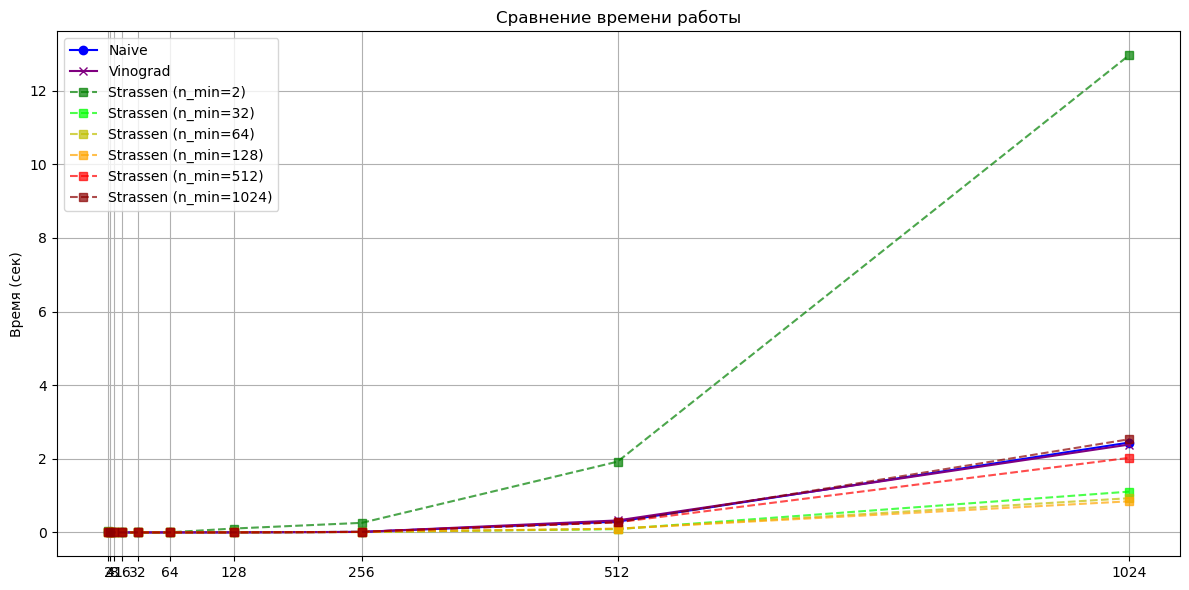

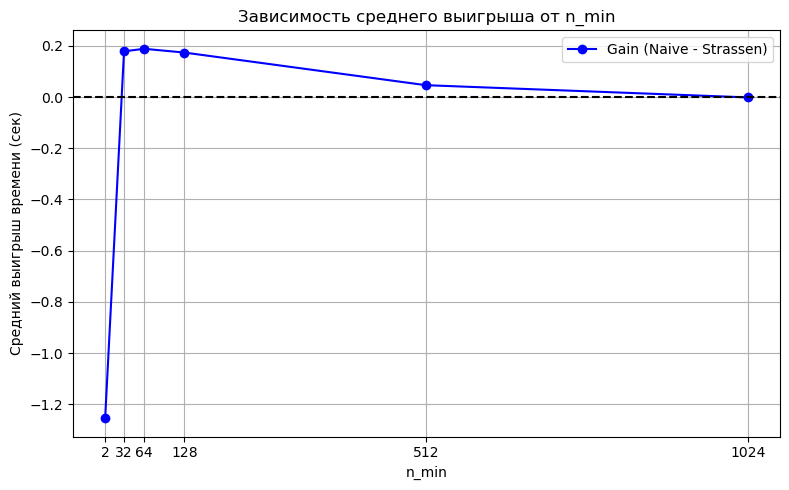

In [15]:
using Random
using LinearAlgebra
using PyPlot
using Statistics

function generate_matrix(l::Int, r::Int, n::Int)    
    return rand(n, n) .* (r - l) .+ l
end

function naive_matrix(A, B)
    n, m = size(A)
    m2, p = size(B)
    C = zeros(eltype(A), n, p)
    
    for i in 1:n
        for j in 1:p
            sum_val = zero(eltype(C))
            for k in 1:m
                sum_val += A[i, k] * B[k, j]
            end
            C[i, j] = sum_val
        end
    end
    return C
end

function vinograd(A, B)
    m, n = size(A)
    n2, p = size(B)    
    d = div(n, 2)
    
    C = zeros(Float64, m, p)
    RowFactor = zeros(Float64, m)
    ColFactor = zeros(Float64, p)
    
    for i in 1:m
        RowFactor[i] = sum(A[i, 2k-1] * A[i, 2k] for k in 1:d)
    end

    for j in 1:p
        ColFactor[j] = sum(B[2k-1, j] * B[2k, j] for k in 1:d)
    end

    for i in 1:m
        for j in 1:p
            s = -RowFactor[i] - ColFactor[j]
            C[i, j] = s + sum((A[i, 2k-1] + B[2k, j]) * (A[i, 2k] + B[2k-1, j]) for k in 1:d)
        end
    end
    
    if isodd(n)
        for i in 1:m
            for j in 1:p
                C[i, j] += A[i, n] * B[n, j]
            end
        end
    end

    return C
end

function strassen(A, B, n_min)
    n = size(A, 1)
    
    if n <= n_min
        return naive_matrix(A, B)
    end     
    
    mid = div(n, 2)
    
    Auu = A[1:mid, 1:mid]       
    Auv = A[1:mid, mid+1:end]   
    Avu = A[mid+1:end, 1:mid]   
    Avv = A[mid+1:end, mid+1:end] 

    Buu = B[1:mid, 1:mid]       
    Buv = B[1:mid, mid+1:end]   
    Bvu = B[mid+1:end, 1:mid]   
    Bvv = B[mid+1:end, mid+1:end] 

    P1 = strassen(Auu + Avv, Buu + Bvv, n_min)
    P2 = strassen(Avu + Avv, Buu, n_min)
    P3 = strassen(Auu, Buv - Bvv, n_min)
    P4 = strassen(Avv, Bvu - Buu, n_min)
    P5 = strassen(Auu + Auv, Bvv, n_min)
    P6 = strassen(Avu - Auu, Buu + Buv, n_min)
    P7 = strassen(Auv - Avv, Bvu + Bvv, n_min)

    Cuu = P1 + P4 - P5 + P7
    Cuv = P3 + P5
    Cvu = P2 + P4
    Cvv = P1 - P2 + P3 + P6

    C = similar(A)
    C[1:mid, 1:mid] = Cuu
    C[1:mid, mid+1:end] = Cuv
    C[mid+1:end, 1:mid] = Cvu
    C[mid+1:end, mid+1:end] = Cvv

    return C
end

dims = [2^i for i in 1:10] 
n_mins_to_test = [2, 32, 64, 128, 512, 1024]


results = Dict{String, Vector{Float64}}()

avg_deltas = Float64[] 

for nm in n_mins_to_test
    sum_delta = 0.0
    current_strass_times = Float64[]
    
    for dim in dims
        A = generate_matrix(-10, 10, dim)
        B = generate_matrix(-10, 10, dim)

        # Naive
        t_start = time()
        naive_matrix(A, B)
        t_naive = time() - t_start

        if nm == n_mins_to_test[1]
            if !haskey(results, "Naive (Standard)")
                results["Naive (Standard)"] = Float64[]
            end
            push!(results["Naive (Standard)"], t_naive)
            
            t_start_v = time()
            vinograd(A, B)
            t_vinograd = time() - t_start_v
            if !haskey(results, "Vinograd")
                results["Vinograd"] = Float64[]
            end
            push!(results["Vinograd"], t_vinograd)
        else
            t_start = time()
            naive_matrix(A, B)
            t_naive = time() - t_start
        end

        t_start = time()
        strassen(A, B, nm) 
        t_strassen = time() - t_start
        push!(current_strass_times, t_strassen)
        delta = t_naive - t_strassen
        sum_delta += delta
    end
    
    results["Strassen (n_min=$nm)"] = current_strass_times
    push!(avg_deltas, sum_delta / length(dims))
end

PyPlot.figure(figsize=(12, 6))
colors = ["g", "lime", "y", "orange", "r", "darkred"]

PyPlot.plot(dims, results["Naive (Standard)"], label="Naive", marker="o", color="b")
PyPlot.plot(dims, results["Vinograd"], label="Vinograd", marker="x", color="purple")

for (i, nm) in enumerate(n_mins_to_test)
    key = "Strassen (n_min=$nm)"
    PyPlot.plot(dims, results[key], label=key, marker="s", linestyle="--", color=colors[i], alpha=0.7)
end

PyPlot.xticks(dims, [string(d) for d in dims])
PyPlot.title("Сравнение времени работы")
PyPlot.ylabel("Время (сек)")
PyPlot.legend()
PyPlot.grid(true)
PyPlot.tight_layout()
PyPlot.show()

PyPlot.figure(figsize=(8, 5))

PyPlot.plot(n_mins_to_test, avg_deltas, marker="o", linestyle="-", color="b", label="Gain (Naive - Strassen)")

PyPlot.xticks(n_mins_to_test) 
PyPlot.xlabel("n_min")
PyPlot.ylabel("Средний выигрыш времени (сек)")
PyPlot.title("Зависимость среднего выигрыша от n_min")
PyPlot.grid(true)
PyPlot.axhline(y=0.0, color="k", linestyle="--")
PyPlot.legend()

PyPlot.tight_layout()
PyPlot.show()